    """
    This was an attempt to see if zg anomalies in G6solar is decaying 
    faster than in G6sulfur. If it did, then it would have meant some
    excitement in my UT-LS hypothesis.
    
    So, now, until I find something intriguing to put me back in this
    persuit, I am abandoning this hypothesis
    """

In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

In [2]:
target_var = "zg"
output_file = "Variance_zg_G6sulfur_and_SSP245_2071-2100.nc"

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    # "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    # "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    # "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    # "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245", "G6solar"):
        return ("2071-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [7]:
def calculate_variance(ds_profile):
    """
    Calculate vertical profile of variance for geopotential height (or other variable).
    
    Computes variance/standard deviation at each pressure level after removing
    zonal mean, to assess amplitude of anomalies and their vertical decay.
    
    Parameters
    ----------
    ds_profile : xr.Dataset
        Dataset containing the target variable (e.g., 'zg') with dimensions 
        (time, plev, lat, lon)
    
    Returns
    -------
    xr.Dataset
        Dataset containing:
        - variance: variance at each level (month, plev, lat)
        - std: standard deviation at each level (month, plev, lat)
        - variance_spatial: variance averaged over lat/lon (month, plev)
        - std_spatial: std averaged over lat/lon (month, plev)
    """
    import xarray as xr
    import numpy as np
    
    # Detect variable name (zg, ta, etc.)
    var_name = [v for v in ds_profile.data_vars if v not in ['time_bnds']][0]
    var = ds_profile[var_name]
    
    print(f"    Computing variance for variable: {var_name}")
    print(f"    Data shape: {var.shape}, dims: {var.dims}")
    
    # Calculate anomalies by removing zonal mean
    var_zonal_mean = var.mean(dim='lon')
    var_anom = var - var_zonal_mean
    
    # Get dimensions
    nmonths = 12
    nlevels = len(var.plev)
    nlat = len(var.lat)
    
    # Initialize output arrays
    variance_monthly = np.full((nmonths, nlevels, nlat), np.nan)
    std_monthly = np.full((nmonths, nlevels, nlat), np.nan)
    variance_spatial = np.full((nmonths, nlevels), np.nan)
    std_spatial = np.full((nmonths, nlevels), np.nan)
    
    # Loop over each month
    for imonth in range(1, 13):
        print(f"    Processing month {imonth}/12")
        
        # Select data for this month
        var_month = var_anom.sel(time=var_anom.time.dt.month == imonth)
        
        if len(var_month.time) == 0:
            print(f"      No data for month {imonth}, skipping")
            continue
        
        # Variance at each level, averaged over time and longitude
        # Result: (plev, lat)
        var_variance = var_month.var(dim=['time', 'lon'])
        var_std = var_month.std(dim=['time', 'lon'])
        
        variance_monthly[imonth-1, :, :] = var_variance.values
        std_monthly[imonth-1, :, :] = var_std.values
        
        # Spatial variance: average over time, lat, lon for each level
        # Result: (plev,)
        var_variance_spatial = var_month.var(dim=['time', 'lat', 'lon'])
        var_std_spatial = var_month.std(dim=['time', 'lat', 'lon'])
        
        variance_spatial[imonth-1, :] = var_variance_spatial.values
        std_spatial[imonth-1, :] = var_std_spatial.values
    
    # Create output dataset
    ds_out = xr.Dataset(
        {
            'variance': (['month', 'plev', 'lat'], variance_monthly),
            'std': (['month', 'plev', 'lat'], std_monthly),
            'variance_spatial': (['month', 'plev'], variance_spatial),
            'std_spatial': (['month', 'plev'], std_spatial),
        },
        coords={
            'month': np.arange(1, 13),
            'plev': var.plev.values,
            'lat': var.lat.values,
        },
        attrs={
            'description': f'Vertical profile of variance for {var_name}',
            'variable': var_name,
            'anomaly_base': 'Zonal mean removed at each time step and level',
            'variance': 'Variance at each level, averaged over time and longitude',
            'variance_spatial': 'Variance at each level, averaged over time, lat, and lon',
            'note': 'Use variance_spatial or std_spatial to assess vertical decay of anomalies'
        }
    )
    
    return ds_out

In [8]:
"""
VARIANCE SECTION
"""


import os

if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)


    # ================================================================
    # MAIN PROCESSING LOOP
    # ================================================================
    
    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        variance_by_exp = {}  # Store all components for each experiment
        seasonal_data = {}      # Store seasonal means by year
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    

            # target_var = "zg" #declared earlier
            base_profile = make_base(target_var)
            
            ds_profile  = load_model_data_alt_path(base_profile, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, target_var)
            
            
            #Slicing data
            t_start, t_end = _time_slice(exp)
            ds_profile = ds_profile.sel(time=slice(t_start, t_end))
            
            # Roll and regrid
            ds_profile = roll_and_regrid_3d(ds_profile, target_lat=30)
            

            print(f"  [{model_name}] {exp}: {target_var} loaded {ds_profile.sizes['time']} months "
                  f"({ds_profile.time.values[0]} → {ds_profile.time.values[-1]})")


            # Calculate variance
            print(f"  [{model_name}] {exp}: Calculating vertical variance")
            variance = calculate_variance(ds_profile)
            
            # Store for this experiment
            variance_by_exp[exp] = variance
            # # For testing purposes - create dummy data
            # variance_by_exp[exp] = xr.Dataset(
            #     {
            #         'variance': (['month', 'plev', 'lat'], np.zeros((12, 19, 25))),
            #         'std': (['month', 'plev', 'lat'], np.zeros((12, 19, 25))),
            #         'variance_spatial': (['month', 'plev'], np.zeros((12, 19))),
            #         'std_spatial': (['month', 'plev'], np.zeros((12, 19))),
            #     },
            #     coords={
            #         'month': np.arange(1, 13),
            #         'plev': ds_profile.plev.values,  # Use actual pressure levels from data
            #         'lat': ds_profile.lat.values,    # Use actual latitudes from data
            #     }
            # )
    
        # After all experiments for this model
        all_results[model_name] = variance_by_exp
    
    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    # Stack all models into one dataset
    model_list = []
    for model_name in all_results.keys():
        exp_list = []
        for exp in EXPERIMENTS.keys():
            if exp in all_results[model_name]:
                ds = all_results[model_name][exp]
                ds = ds.expand_dims({'experiment': [exp]})
                exp_list.append(ds)
        
        # Combine experiments for this model
        if exp_list:
            ds_model = xr.concat(exp_list, dim='experiment')
            ds_model = ds_model.expand_dims({'model': [model_name]})
            model_list.append(ds_model)
    
    # Combine all models
    ds_combined = xr.concat(model_list, dim='model')
    
    # Save
    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions: {dict(ds_combined.dims)}")
    print(f"  Variables: {list(ds_combined.data_vars)}")

else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
File does not exist — running code
########################################
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/zg/gn/latest
  [UKESM1-0-LL] G6sulfur: zg loaded 360 months (2071-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: Calculating vertical variance
    Computing variance for variable: zg
    Data shape: (19, 360, 25, 144), dims: ('plev', 'time', 'lat', 'lon')
    Processing month 1/12
    Processing month 2/12
    Processing month 3/12
    Processing month 4/12
    Processing month 5/12
    Processing month 6/12
    Processing month 7/12
    Processing month 8/12
    Processing month 9/12
    Processing month 10/12
    Processing month 11/12
    Processing month 12/12
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/zg/gn/latest
  [UKESM1-0-LL] SSP245: zg loaded 360 months (2071-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] SSP245: Calculating vertical varia

## Plotting 

In [11]:
# Load the dataset
ds_variance = xr.open_dataset(output_file)
# ds_sorted = xr.open_dataset('Omega_sorted_G6sulfur_and_SSP245.nc')

In [12]:
print('ds_variance',ds_variance)

ds_variance <xarray.Dataset> Size: 190kB
Dimensions:           (model: 1, experiment: 2, month: 12, plev: 19, lat: 25)
Coordinates:
  * model             (model) <U11 44B 'UKESM1-0-LL'
  * experiment        (experiment) <U8 64B 'G6sulfur' 'SSP245'
  * month             (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev              (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 500.0 100.0
  * lat               (lat) float64 200B -30.0 -27.5 -25.0 ... 25.0 27.5 30.0
Data variables:
    variance          (model, experiment, month, plev, lat) float64 91kB ...
    std               (model, experiment, month, plev, lat) float64 91kB ...
    variance_spatial  (model, experiment, month, plev) float64 4kB ...
    std_spatial       (model, experiment, month, plev) float64 4kB ...
Attributes:
    description:       Vertical profile of variance for zg
    variable:          zg
    anomaly_base:      Zonal mean removed at each time step and level
    variance:          Variance at each level, 

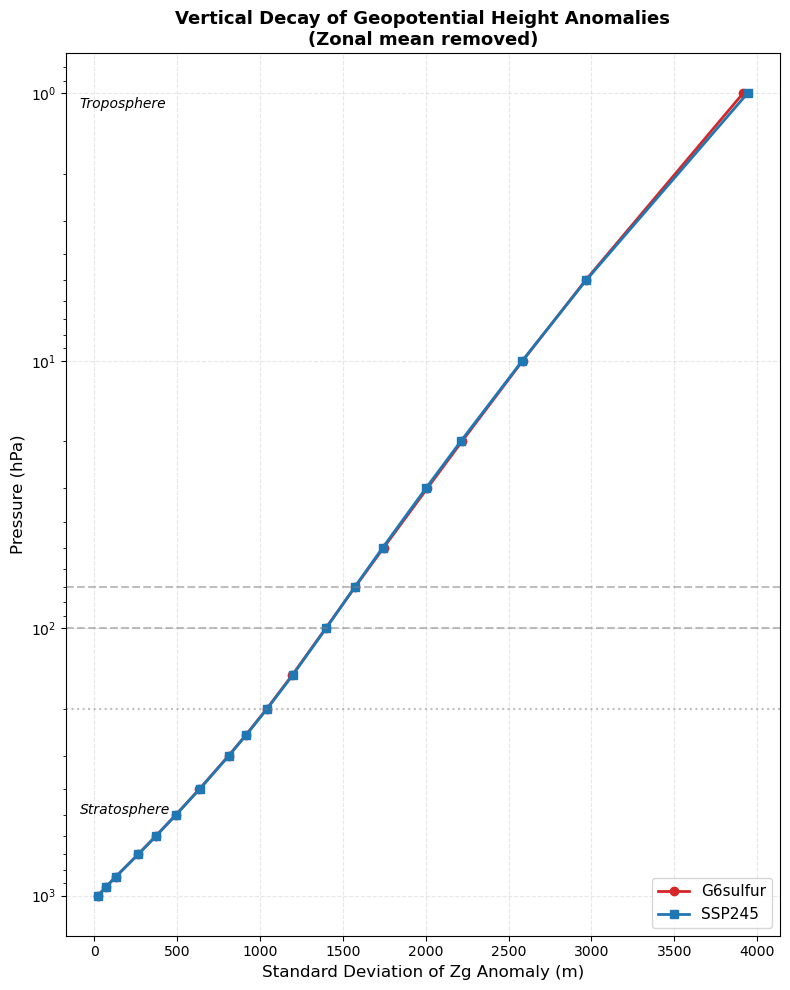


Decay metrics (LS/UT amplitude ratio):
G6sulfur: 1.512
G6solar:  1.507

Lower ratio → faster decay
✗ G6solar decays faster


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Select model
model = 'UKESM1-0-LL'

# Extract data for both experiments
std_g6sulfur = ds_variance.sel(model=model, experiment='G6sulfur')['std_spatial']
std_g6solar = ds_variance.sel(model=model, experiment=EXP2)['std_spatial']

# Average over months (or select specific season)
# For annual mean:
std_sulfur_ann = std_g6sulfur.mean(dim='month')
std_solar_ann = std_g6solar.mean(dim='month')

# OR for specific season (e.g., DJF):
# std_sulfur_djf = std_g6sulfur.sel(month=[12,1,2]).mean(dim='month')
# std_solar_djf = std_g6solar.sel(month=[12,1,2]).mean(dim='month')

# Get pressure levels in hPa
pressure = ds_variance.plev.values / 100  # Convert Pa to hPa

# Create the plot
fig, ax = plt.subplots(figsize=(8, 10))

ax.plot(std_sulfur_ann, pressure, 'o-', linewidth=2, markersize=6, 
        label='G6sulfur', color='tab:red')
ax.plot(std_solar_ann, pressure, 's-', linewidth=2, markersize=6, 
        label=EXP2, color='tab:blue')

# Formatting
ax.set_yscale('log')
ax.invert_yaxis()  # High altitude at top
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_xlabel('Standard Deviation of Zg Anomaly (m)', fontsize=12)
ax.set_title('Vertical Decay of Geopotential Height Anomalies\n(Zonal mean removed)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best')

# Add horizontal lines to mark UT and LS regions
ax.axhline(200, color='gray', linestyle=':', alpha=0.5, label='UT (~200 hPa)')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='LS (~100 hPa)')
ax.axhline(70, color='gray', linestyle='--', alpha=0.5)

# Add text annotations
ax.text(0.02, 0.95, 'Troposphere', transform=ax.transAxes, 
        fontsize=10, va='top', style='italic')
ax.text(0.02, 0.15, 'Stratosphere', transform=ax.transAxes, 
        fontsize=10, va='top', style='italic')

plt.tight_layout()
plt.show()

# Quantify decay rate
# Calculate ratio of LS/UT amplitude
ut_level = 200  # hPa
ls_level = 70   # hPa

ratio_sulfur = (std_sulfur_ann.sel(plev=ls_level*100, method='nearest') / 
                std_sulfur_ann.sel(plev=ut_level*100, method='nearest'))
ratio_solar = (std_solar_ann.sel(plev=ls_level*100, method='nearest') / 
               std_solar_ann.sel(plev=ut_level*100, method='nearest'))

print(f"\nDecay metrics (LS/UT amplitude ratio):")
print(f"G6sulfur: {ratio_sulfur.values:.3f}")
print(f"G6solar:  {ratio_solar.values:.3f}")
print(f"\nLower ratio → faster decay")
if ratio_sulfur < ratio_solar:
    print(f"✓ G6sulfur decays {((ratio_solar-ratio_sulfur)/ratio_solar*100).values:.1f}% faster")
else:
    print(f"✗ G6solar decays faster")

In [14]:
from scipy.optimize import curve_fit

# Define exponential decay function
def exp_decay(z, A, H):
    """A * exp(-z/H), where H is e-folding height"""
    return A * np.exp(-z / H)

# Convert pressure to approximate height (log-pressure height)
# z ≈ -H_scale * ln(p/p0), where H_scale ~ 7 km
H_scale = 7000  # meters
p0 = 1000  # hPa reference
height = -H_scale * np.log(pressure / p0)

# Fit in UT-to-LS region (e.g., 300-50 hPa)
mask = (pressure <= 300) & (pressure >= 50)

# Fit G6sulfur
params_sulfur, _ = curve_fit(exp_decay, height[mask], std_sulfur_ann.values[mask])
print(f"\nG6sulfur e-folding height: {params_sulfur[1]/1000:.2f} km")

# Fit G6solar
params_solar, _ = curve_fit(exp_decay, height[mask], std_solar_ann.values[mask])
print(f"G6solar e-folding height: {params_solar[1]/1000:.2f} km")
print(f"\nSmaller e-folding height → faster vertical decay")


G6sulfur e-folding height: 0.00 km
G6solar e-folding height: 0.00 km

Smaller e-folding height → faster vertical decay
